# QRE2 Shifted Operator Handoff

This notebook is the supervision artifact for the first `QRE2` migration from `QCFD_3` into this repository. It shows the paper anchors, the lean shifted-D2Q9 adaptation, the numerical checks, and the pre-Carleman gate.

Pedagogical sequence: paper anchor -> compact equation -> operator or matrix object -> observable plot -> falsifiable check.

The implementation lives in `src/pq_cfd/_qre2_shifted.py`. It is private/internal, meaning usable by notebooks and tests but not promoted as a stable public package API. The audit trail lives in `docs/qre2_migration_audit.md`.

## Paper And Migration Anchors

The authority is the paper, not the previous code. `QCFD_3` is engineering evidence only; each migrated concept must tie back to `QRE2`.

| Concept | QRE2 anchor | Current implementation |
| --- | --- | --- |
| shifted variable | `sec:shifted`, `eq:g` | `shift_to_g`, `unshift_to_fbar` |
| shifted moments | `sec:shifted`, `eq:eq_shift_incompressible` | `shifted_moments` |
| shifted equilibrium | `sec:shifted`, `eq:eq_shift_incompressible`, `eq:eq_shift_explicit` | `shifted_equilibrium`, `shifted_equilibrium_from_moments` |
| polynomial collision | `sec:shifted`, `eq:LBE_col_shift_matrix`, `eq:F1`, `eq:F2` | `build_shifted_collision_terms` |
| periodic streaming | `sec:shifted`, `eq:streaming` | `build_streaming_matrix` |
| direct versus polynomial update | `eq:LBE_col_shift`, `eq:LBE_str_shift`, `eq:LBE_col_shift_matrix` | `step_shifted_direct`, `step_shifted_matrix` |

Every implementation cell below cites `QRE2` and the relevant equation family.

In [1]:
# Corpus anchor: QRE2 (`sec:shifted`, `eq:g`, `eq:eq_shift_incompressible`, `eq:eq_shift_explicit`, `eq:LBE_col_shift_matrix`, `eq:F1`, `eq:F2`, `eq:streaming`).
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import pq_cfd
from pq_cfd import SimulationConfig, run_d2q9
from pq_cfd import _qre2_shifted as qre2
from pq_cfd.d2q9 import D2Q9_C, D2Q9_W, analytic_taylor_green_velocity
from pq_cfd.d2q9_diagnostics import (
    grid_spacings,
    max_mach_number,
    mean_kinetic_energy,
    normalized_l2_norm,
    periodic_divergence,
    periodic_vorticity,
    relative_scalar_error,
)
from pq_cfd.metrics import relative_l2_error

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 130})


def speed(velocity):
    return np.sqrt(velocity[0] ** 2 + velocity[1] ** 2)


def flatten_field_for_heatmap(g):
    return np.moveaxis(g, 0, -1).reshape(-1, 9)


def linear_shifted_state(delta_rho: np.ndarray, velocity: np.ndarray) -> np.ndarray:
    g = np.empty((9, *delta_rho.shape))
    for index, (cx, cy) in enumerate(D2Q9_C):
        c_dot_u = cx * velocity[0] + cy * velocity[1]
        g[index] = D2Q9_W[index] * (delta_rho + 3.0 * c_dot_u)
    return g


def small_shifted_state(spatial_shape: tuple[int, int]) -> np.ndarray:
    nx, ny = spatial_shape
    x = np.arange(nx, dtype=float)[:, None]
    y = np.arange(ny, dtype=float)[None, :]
    delta = 0.01 * np.cos(2.0 * np.pi * (x + y) / (nx + ny))
    u = np.zeros((2, nx, ny))
    u[0] = 0.02 * np.sin(2.0 * np.pi * (x + 1.0) / (nx + 1.0))
    u[1] = -0.015 * np.cos(2.0 * np.pi * (y + 1.0) / (ny + 1.0))
    return qre2.shifted_equilibrium_from_moments(delta, u)


def assert_f2_same_site_only(f2, spatial_shape):
    site_count = int(np.prod(spatial_shape))
    dimension = site_count * 9
    rows, cols = np.nonzero(np.abs(f2) > 1e-15)
    row_sites = rows // 9
    first_factor_sites = (cols // dimension) // 9
    second_factor_sites = (cols % dimension) // 9
    residual = int(np.count_nonzero((row_sites != first_factor_sites) | (row_sites != second_factor_sites)))
    assert residual == 0
    return rows.size, residual

print(f"project_root={project_root}")
print(f"public_api_contains_qre2={any('qre2' in name.lower() for name in pq_cfd.__all__)}")

project_root=c:\Users\NishchayVORA\Documents\PQ_CFD
public_api_contains_qre2=False


## Shifted State And Site-Major Layout

`QRE2` shifts the populations by subtracting the equilibrium weights:

$$
g_i=\bar f_i-w_i.
$$

The shifted moments are:

$$
\delta\rho=\sum_i g_i,\qquad \mathbf{u}=\sum_i \mathbf{c}_i g_i.
$$

This repository stores fields as `(9, nx, ny)` for solver consistency, then flattens tiny dense validation vectors as `(site, velocity)`. The plot below shows both the flattening map and the moment-extraction matrix.

shift/moment residuals
shift roundtrip=2.689e-17
delta_rho=6.939e-18
velocity=6.939e-18


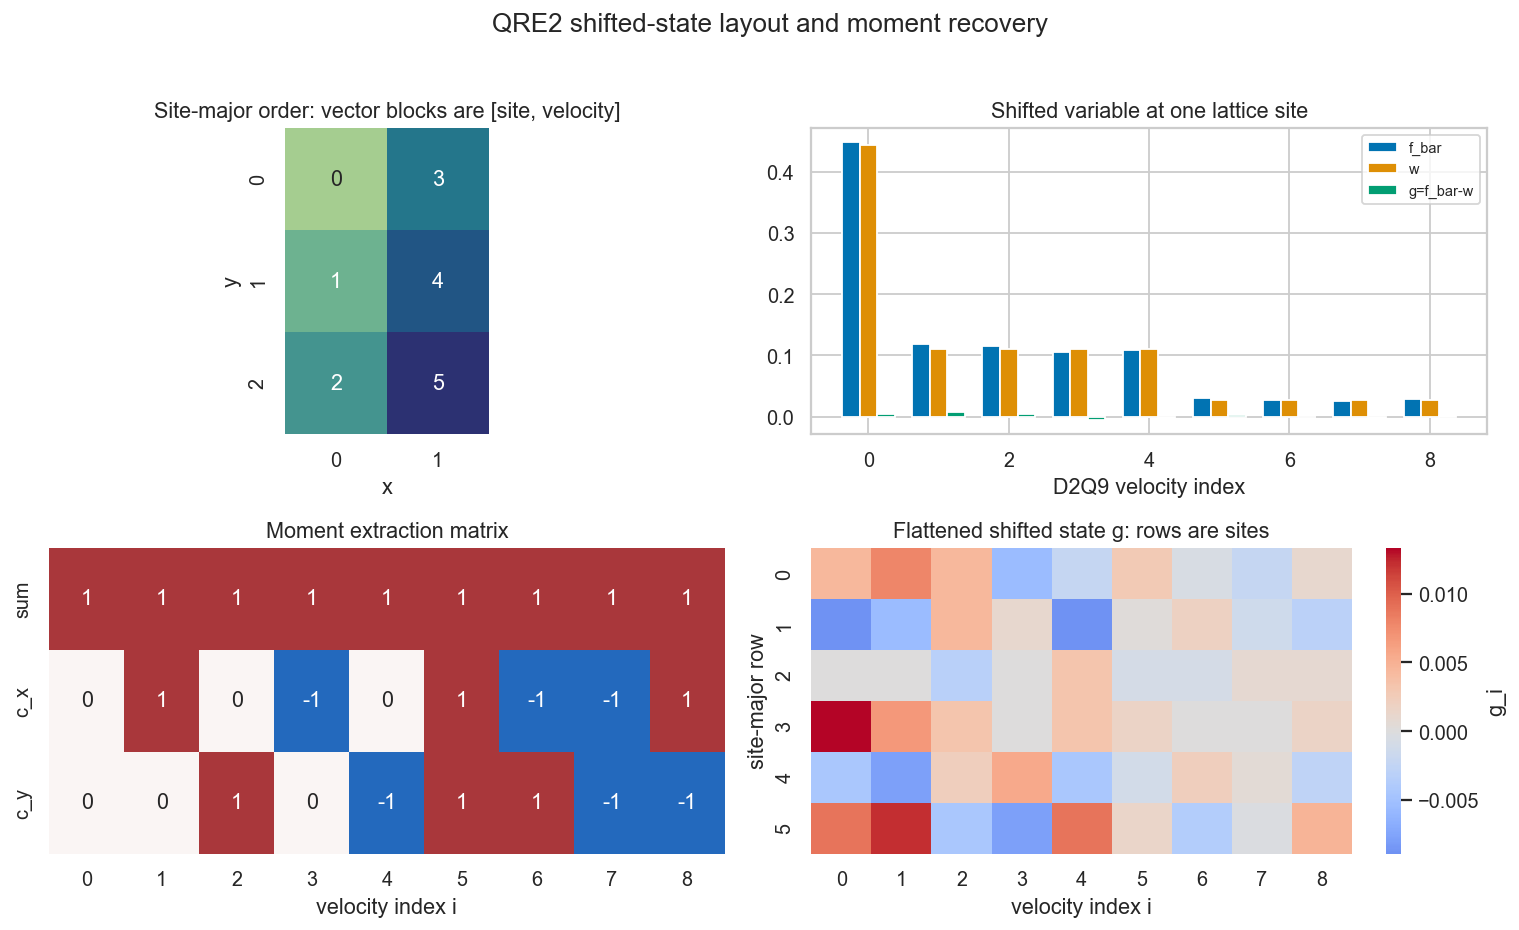

In [2]:
# Corpus anchor: QRE2 (`eq:g`, `eq:eq_shift_incompressible`). Shift, moment, and site-major layout checks.
delta_rho = np.array([[0.01, -0.02, 0.0], [0.03, -0.01, 0.02]])
velocity = np.zeros((2, *delta_rho.shape))
velocity[0] = [[0.02, -0.01, 0.0], [0.01, -0.02, 0.03]]
velocity[1] = [[0.01, 0.02, -0.01], [0.0, 0.01, -0.02]]
g = linear_shifted_state(delta_rho, velocity)
f_bar = qre2.unshift_to_fbar(g)
roundtrip = qre2.shift_to_g(f_bar)
recovered_delta, recovered_velocity = qre2.shifted_moments(g)
shift_residual = np.max(np.abs(roundtrip - g))
delta_residual = np.max(np.abs(recovered_delta - delta_rho))
velocity_residual = np.max(np.abs(recovered_velocity - velocity))
site_ids = np.arange(delta_rho.size).reshape(delta_rho.shape)
moment_matrix = np.vstack([np.ones(9), D2Q9_C[:, 0], D2Q9_C[:, 1]])
site = (0, 0)
_fig, _axes = plt.subplots(2, 2, figsize=(12, 7))
sns.heatmap(site_ids.T, annot=True, fmt='d', cmap='crest', cbar=False, ax=_axes[0, 0], square=True)
_axes[0, 0].set_title('Site-major order: vector blocks are [site, velocity]')
_axes[0, 0].set_xlabel('x')
_axes[0, 0].set_ylabel('y')
velocity_indices = np.arange(9)
_axes[0, 1].bar(velocity_indices - 0.25, f_bar[:, *site], width=0.25, label='f_bar')
_axes[0, 1].bar(velocity_indices, D2Q9_W, width=0.25, label='w')
_axes[0, 1].bar(velocity_indices + 0.25, g[:, *site], width=0.25, label='g=f_bar-w')
_axes[0, 1].set_title('Shifted variable at one lattice site')
_axes[0, 1].set_xlabel('D2Q9 velocity index')
_axes[0, 1].legend(fontsize=8)
sns.heatmap(moment_matrix, annot=True, fmt='.0f', cmap='vlag', center=0, cbar=False, ax=_axes[1, 0], xticklabels=range(9), yticklabels=['sum', 'c_x', 'c_y'])
_axes[1, 0].set_title('Moment extraction matrix')
_axes[1, 0].set_xlabel('velocity index i')
flat_g = flatten_field_for_heatmap(g)
sns.heatmap(flat_g, cmap='coolwarm', center=0, ax=_axes[1, 1], cbar_kws={'label': 'g_i'}, xticklabels=range(9))
_axes[1, 1].set_title('Flattened shifted state g: rows are sites')
_axes[1, 1].set_xlabel('velocity index i')
_axes[1, 1].set_ylabel('site-major row')
_fig.suptitle('QRE2 shifted-state layout and moment recovery', y=1.02)
_fig.tight_layout()
print('shift/moment residuals')
print(f'shift roundtrip={shift_residual:.3e}')
print(f'delta_rho={delta_residual:.3e}')
print(f'velocity={velocity_residual:.3e}')
assert shift_residual < 1e-15
assert delta_residual < 1e-15
assert velocity_residual < 1e-15

## Shifted Equilibrium Formula

`QRE2` uses an incompressible shifted equilibrium:

$$
g_i^{eq}=w_i\left[\delta\rho+3\mathbf{c}_i\cdot\mathbf{u}+4.5(\mathbf{c}_i\cdot\mathbf{u})^2-1.5\mathbf{u}\cdot\mathbf{u}\right].
$$

The visual check separates density, linear velocity, and quadratic velocity terms at one site, then compares the explicit formula to the package helper.

equilibrium residuals
explicit formula=3.469e-18
density moment=6.939e-18
velocity moment=6.939e-18


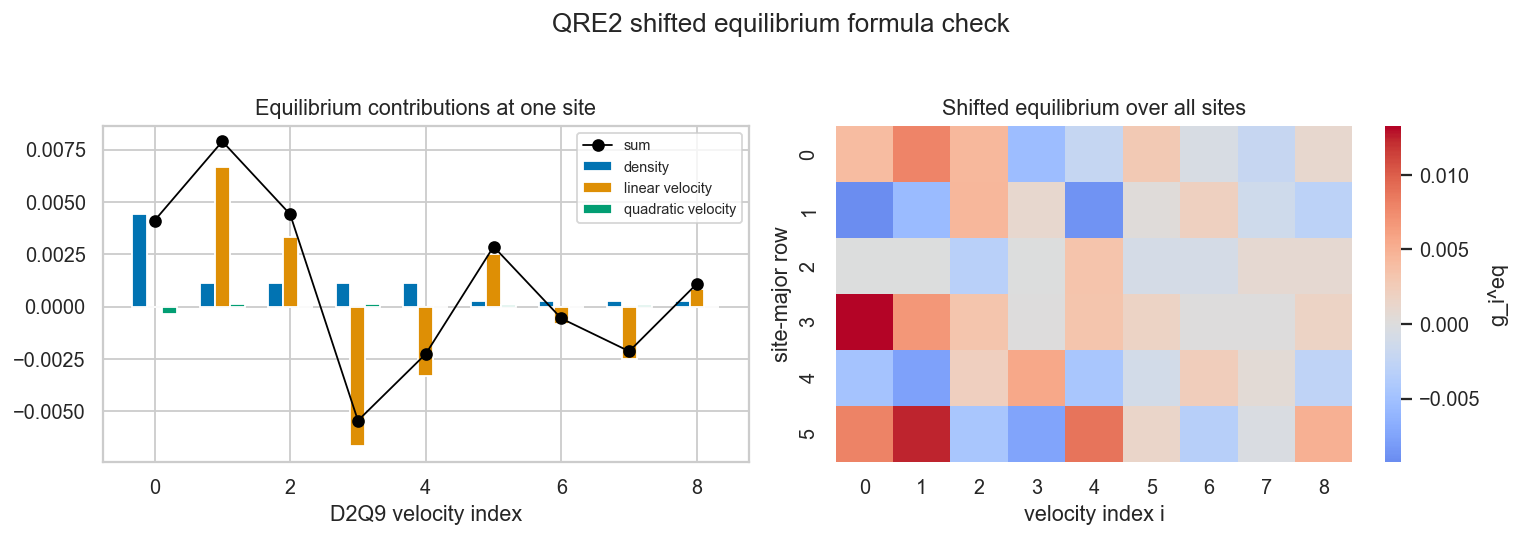

In [3]:
# Corpus anchor: QRE2 (`eq:eq_shift_incompressible`, `eq:eq_shift_explicit`). Explicit equilibrium formula check.
def explicit_qre2_equilibrium(delta_rho: np.ndarray, velocity: np.ndarray) -> np.ndarray:
    equilibrium = np.empty((9, *delta_rho.shape))
    speed_squared = velocity[0] ** 2 + velocity[1] ** 2
    for index, (cx, cy) in enumerate(D2Q9_C):
        c_dot_u = cx * velocity[0] + cy * velocity[1]
        equilibrium[index] = D2Q9_W[index] * (delta_rho + 3.0 * c_dot_u + 4.5 * c_dot_u ** 2 - 1.5 * speed_squared)
    return equilibrium
actual_equilibrium = qre2.shifted_equilibrium(g)
expected_equilibrium = explicit_qre2_equilibrium(delta_rho, velocity)
equilibrium_residual = np.max(np.abs(actual_equilibrium - expected_equilibrium))
equilibrium_delta, equilibrium_velocity = qre2.shifted_moments(actual_equilibrium)
equilibrium_delta_residual = np.max(np.abs(equilibrium_delta - delta_rho))
equilibrium_velocity_residual = np.max(np.abs(equilibrium_velocity - velocity))
sx, sy = site
speed_squared = velocity[0, sx, sy] ** 2 + velocity[1, sx, sy] ** 2
c_dot_u = D2Q9_C[:, 0] * velocity[0, sx, sy] + D2Q9_C[:, 1] * velocity[1, sx, sy]
term_density = D2Q9_W * delta_rho[sx, sy]
term_linear = D2Q9_W * 3.0 * c_dot_u
term_quadratic = D2Q9_W * (4.5 * c_dot_u ** 2 - 1.5 * speed_squared)
_fig, _axes = plt.subplots(1, 2, figsize=(12, 4))
width = 0.22
_axes[0].bar(velocity_indices - width, term_density, width=width, label='density')
_axes[0].bar(velocity_indices, term_linear, width=width, label='linear velocity')
_axes[0].bar(velocity_indices + width, term_quadratic, width=width, label='quadratic velocity')
_axes[0].plot(velocity_indices, actual_equilibrium[:, sx, sy], color='black', marker='o', linewidth=1, label='sum')
_axes[0].set_title('Equilibrium contributions at one site')
_axes[0].set_xlabel('D2Q9 velocity index')
_axes[0].legend(fontsize=8)
sns.heatmap(flatten_field_for_heatmap(actual_equilibrium), cmap='coolwarm', center=0, ax=_axes[1], cbar_kws={'label': 'g_i^eq'}, xticklabels=range(9))
_axes[1].set_title('Shifted equilibrium over all sites')
_axes[1].set_xlabel('velocity index i')
_axes[1].set_ylabel('site-major row')
_fig.suptitle('QRE2 shifted equilibrium formula check', y=1.03)
_fig.tight_layout()
print('equilibrium residuals')
print(f'explicit formula={equilibrium_residual:.3e}')
print(f'density moment={equilibrium_delta_residual:.3e}')
print(f'velocity moment={equilibrium_velocity_residual:.3e}')
assert equilibrium_residual < 1e-15
assert equilibrium_delta_residual < 1e-15
assert equilibrium_velocity_residual < 1e-15

## Streaming Matrix And Flattening Check

The paper matrix acts on a flattened vector. The repository field layout is converted only for tiny dense validation.

The streaming check has two parts:

$$
S^T S=I,\qquad S\,\mathrm{vec}(g)=\mathrm{vec}(\mathrm{roll}_{periodic}(g)).
$$

This makes periodic streaming a visible permutation rather than an implicit array shift.

streaming/layout residuals
layout=0.000e+00
S.T @ S - I=0.000e+00
matrix-vs-roll=0.000e+00


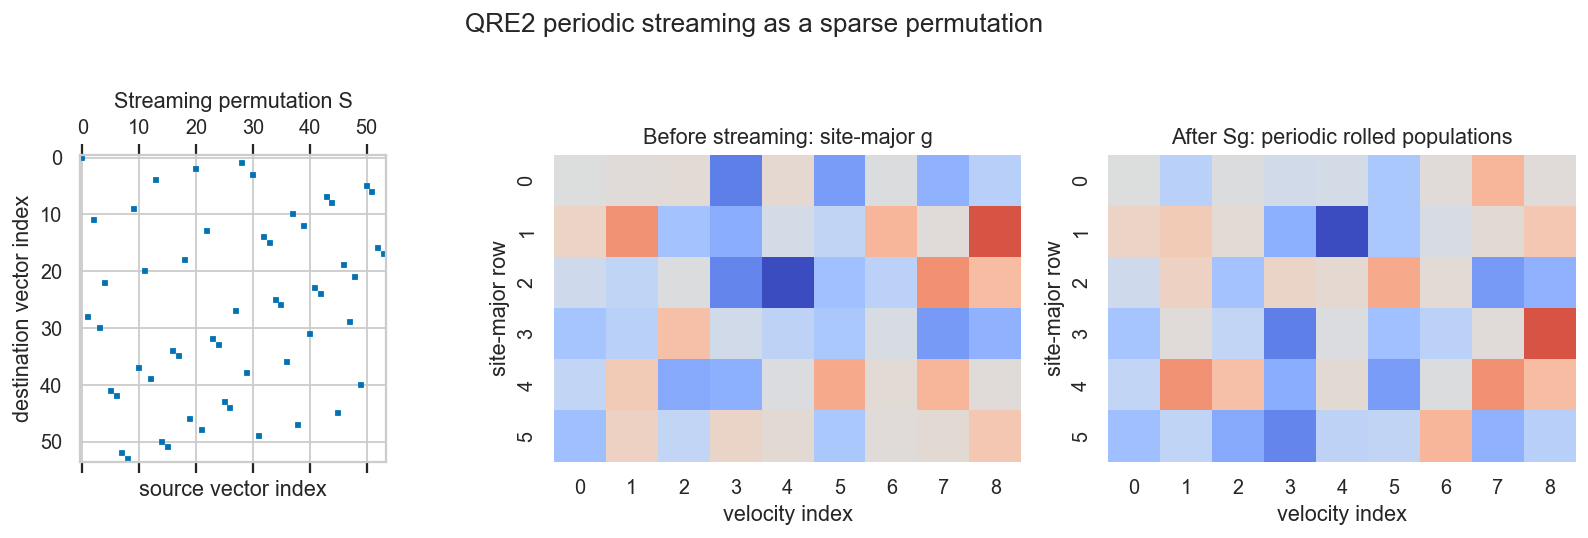

In [4]:
# Corpus anchor: QRE2 (`eq:streaming`). Periodic streaming matrix and layout check.
def manual_stream_periodic(distributions: np.ndarray) -> np.ndarray:
    streamed = np.empty_like(distributions)
    for index, (cx, cy) in enumerate(D2Q9_C):
        streamed[index] = np.roll(distributions[index], shift=(int(cx), int(cy)), axis=(0, 1))
    return streamed
spatial_shape = (2, 3)
rng = np.random.default_rng(7)
random_g = rng.normal(scale=0.02, size=(9, *spatial_shape))
_streaming = qre2.build_streaming_matrix(spatial_shape)
flat = qre2.flatten_site_major(random_g)
unflattened = qre2.unflatten_site_major(flat, spatial_shape)
streamed_from_matrix = qre2.unflatten_site_major(_streaming @ flat, spatial_shape)
streamed_direct = manual_stream_periodic(random_g)
layout_residual = np.max(np.abs(unflattened - random_g))
permutation_residual = np.max(np.abs(_streaming.T @ _streaming - np.eye(_streaming.shape[0])))
streaming_residual = np.max(np.abs(streamed_from_matrix - streamed_direct))
_fig, _axes = plt.subplots(1, 3, figsize=(13, 4))
_axes[0].spy(_streaming, markersize=2)
_axes[0].set_title('Streaming permutation S')
_axes[0].set_xlabel('source vector index')
_axes[0].set_ylabel('destination vector index')
sns.heatmap(flatten_field_for_heatmap(random_g), cmap='coolwarm', center=0, ax=_axes[1], cbar=False, xticklabels=range(9))
_axes[1].set_title('Before streaming: site-major g')
_axes[1].set_xlabel('velocity index')
_axes[1].set_ylabel('site-major row')
sns.heatmap(flatten_field_for_heatmap(streamed_from_matrix), cmap='coolwarm', center=0, ax=_axes[2], cbar=False, xticklabels=range(9))
_axes[2].set_title('After Sg: periodic rolled populations')
_axes[2].set_xlabel('velocity index')
_axes[2].set_ylabel('site-major row')
_fig.suptitle('QRE2 periodic streaming as a sparse permutation', y=1.03)
_fig.tight_layout()
print('streaming/layout residuals')
print(f'layout={layout_residual:.3e}')
print(f'S.T @ S - I={permutation_residual:.3e}')
print(f'matrix-vs-roll={streaming_residual:.3e}')
assert layout_residual < 1e-15
assert permutation_residual < 1e-15
assert streaming_residual < 1e-15

## Polynomial Operator Gate Before Carleman

The shifted collision is local and quadratic before streaming:

$$
g^C=(I+F_1)g+F_2(g\otimes g),\qquad g(t+1)=Sg^C.
$$

The visible objects below are exactly the objects a later Carleman lift will consume: `S`, `F1`, `F2`, `g`, and `g tensor g`.

operator ledger
g: shape=(36,), nonzero=36, density=1.000e+00
S: shape=(36, 36), nonzero=36, density=2.778e-02
F1: shape=(36, 36), nonzero=324, density=2.500e-01
F2: shape=(36, 1296), nonzero=1984, density=4.252e-02
g_tensor: shape=(1296,), nonzero=1296, density=1.000e+00
F2 same-site nonzeros=1984, violations=0
one-step direct/matrix residual=8.674e-19


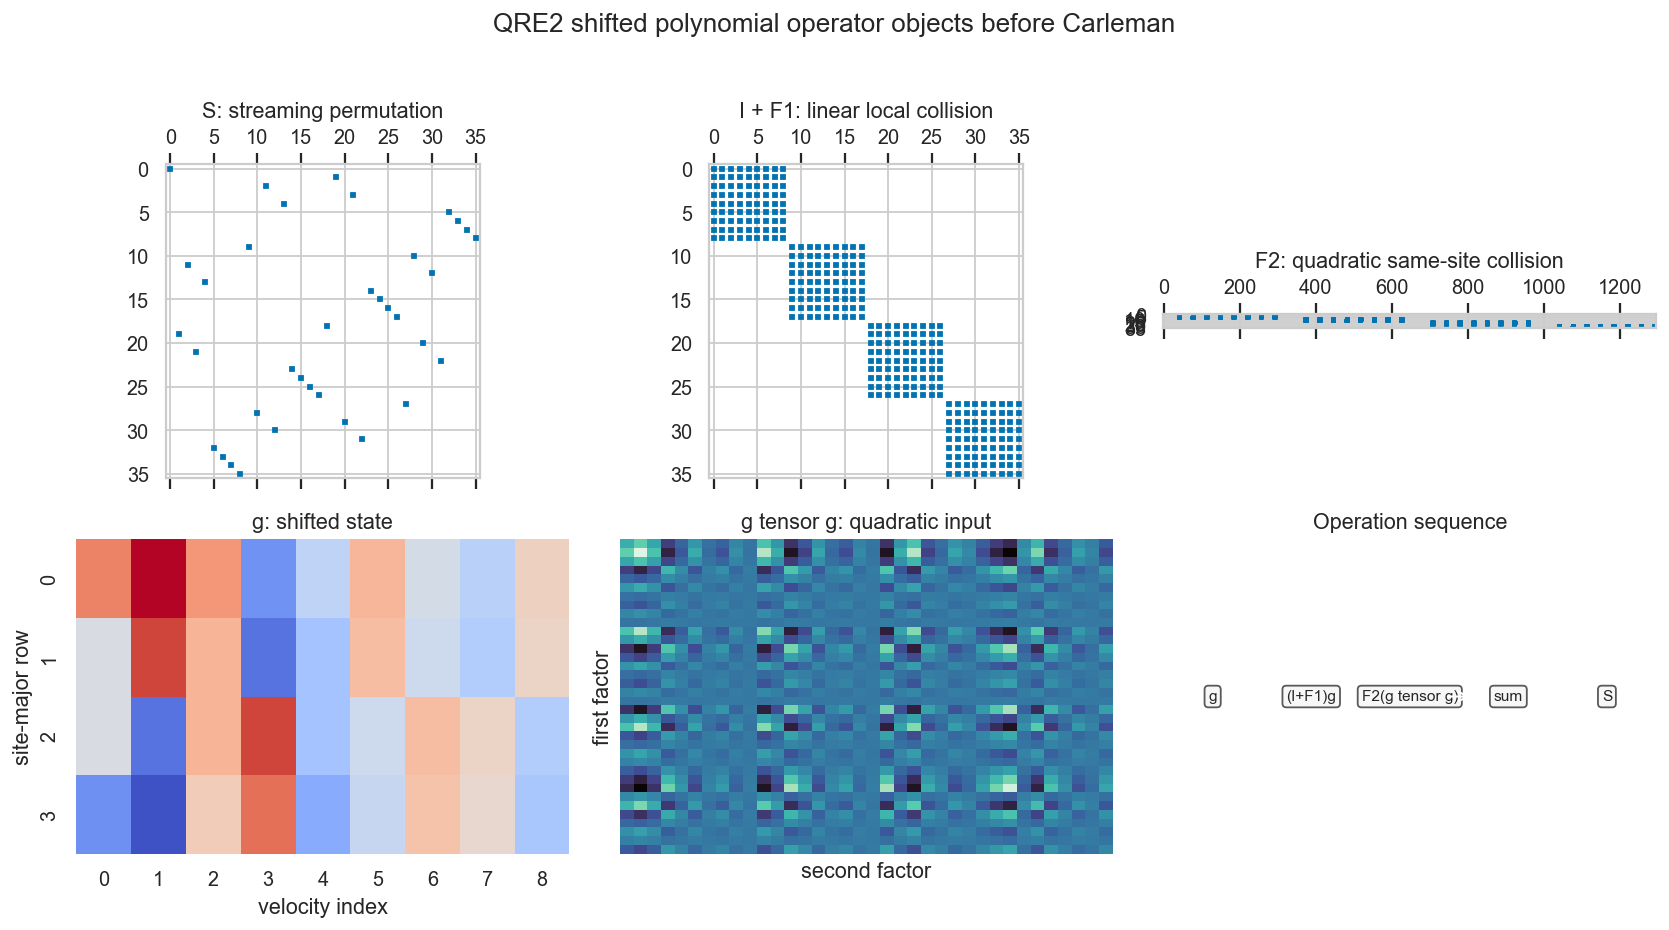

In [5]:
# Corpus anchor: QRE2 (`eq:LBE_col_shift_matrix`, `eq:F1`, `eq:F2`, `eq:streaming`). Dense tiny operator object and one-step check.
tiny_shape = (2, 2)
tiny_tau = 0.8
tiny_g = small_shifted_state(tiny_shape)
tiny_g_vec = qre2.flatten_site_major(tiny_g)
local_f1, local_f2 = qre2.build_shifted_collision_terms(tiny_tau)
global_f1, global_f2 = qre2.build_shifted_collision_terms(tiny_tau, tiny_shape)
_streaming = qre2.build_streaming_matrix(tiny_shape)
identity = np.eye(tiny_g_vec.size)
g_tensor = np.kron(tiny_g_vec, tiny_g_vec)
matrix_next = qre2.unflatten_site_major(qre2.step_shifted_matrix(tiny_g_vec, _streaming, global_f1, global_f2), tiny_shape)
direct_next = qre2.step_shifted_direct(tiny_g, tiny_tau)
one_step_residual = np.max(np.abs(matrix_next - direct_next))
f2_nonzero, f2_site_residual = assert_f2_same_site_only(global_f2, tiny_shape)
_fig, _axes = plt.subplots(2, 3, figsize=(13, 7))
_axes[0, 0].spy(_streaming, markersize=1.8)
_axes[0, 0].set_title('S: streaming permutation')
_axes[0, 1].spy(np.abs(identity + global_f1) > 1e-15, markersize=1.8)
_axes[0, 1].set_title('I + F1: linear local collision')
_axes[0, 2].spy(np.abs(global_f2) > 1e-15, markersize=0.45)
_axes[0, 2].set_title('F2: quadratic same-site collision')
sns.heatmap(flatten_field_for_heatmap(tiny_g), cmap='coolwarm', center=0, ax=_axes[1, 0], cbar=False, xticklabels=range(9))
_axes[1, 0].set_title('g: shifted state')
_axes[1, 0].set_xlabel('velocity index')
_axes[1, 0].set_ylabel('site-major row')
sns.heatmap(g_tensor.reshape(tiny_g_vec.size, tiny_g_vec.size), cmap='mako', ax=_axes[1, 1], cbar=False, xticklabels=False, yticklabels=False)
_axes[1, 1].set_title('g tensor g: quadratic input')
_axes[1, 1].set_xlabel('second factor')
_axes[1, 1].set_ylabel('first factor')
_ax = _axes[1, 2]
sequence = ['g', '(I+F1)g', 'F2(g tensor g)', 'sum', 'S']
for index, label in enumerate(sequence):
    _ax.text(index, 0.5, label, ha='center', va='center', fontsize=8.5, bbox={'boxstyle': 'round,pad=0.25', 'fc': '#f7f7f7', 'ec': '0.35'})
    if index < len(sequence) - 1:
        _ax.annotate('', xy=(index + 0.65, 0.5), xytext=(index + 0.35, 0.5), arrowprops={'arrowstyle': '->', 'lw': 1.2})
_ax.set_xlim(-0.5, len(sequence) - 0.5)
_ax.set_ylim(0, 1)
_ax.axis('off')
_ax.set_title('Operation sequence')
_fig.suptitle('QRE2 shifted polynomial operator objects before Carleman', y=1.02)
_fig.tight_layout()
print('operator ledger')
for name, array in [('g', tiny_g_vec), ('S', _streaming), ('F1', global_f1), ('F2', global_f2), ('g_tensor', g_tensor)]:
    arr = np.asarray(array)
    nonzero = int(np.count_nonzero(np.abs(arr) > 1e-15))
    density = nonzero / arr.size
    print(f'{name}: shape={arr.shape}, nonzero={nonzero}, density={density:.3e}')
print(f'F2 same-site nonzeros={f2_nonzero}, violations={f2_site_residual}')
print(f'one-step direct/matrix residual={one_step_residual:.3e}')
assert one_step_residual < 1e-12
assert f2_site_residual == 0

six-step direct/matrix residual=4.337e-18


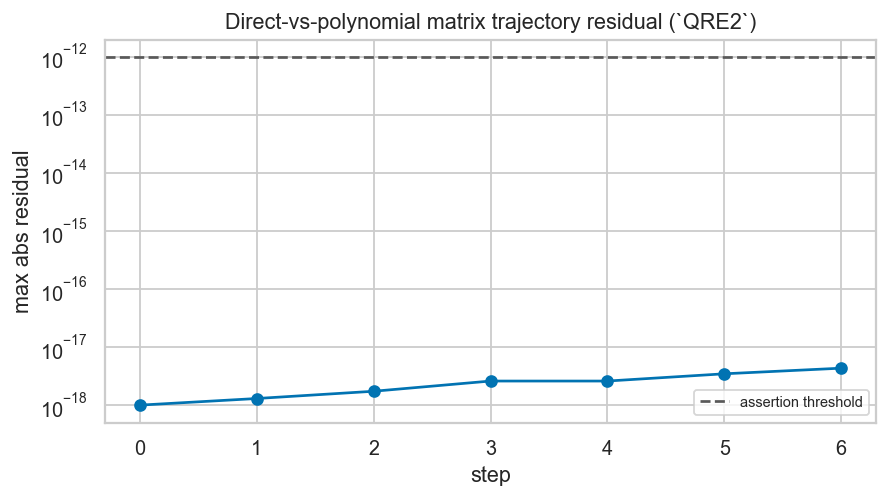

In [6]:
# Corpus anchor: QRE2 (`eq:LBE_col_shift`, `eq:LBE_str_shift`, `eq:LBE_col_shift_matrix`). Direct-vs-matrix trajectory residual.
tau_bar = 0.91
f1, f2 = qre2.build_shifted_collision_terms(tau_bar, tiny_shape)
_streaming = qre2.build_streaming_matrix(tiny_shape)
direct = small_shifted_state(tiny_shape)
matrix_vector = qre2.flatten_site_major(direct)
trajectory_residuals = [0.0]
for _ in range(6):
    direct = qre2.step_shifted_direct(direct, tau_bar)
    matrix_vector = qre2.step_shifted_matrix(matrix_vector, _streaming, f1, f2)
    matrix = qre2.unflatten_site_major(matrix_vector, tiny_shape)
    trajectory_residuals.append(float(np.max(np.abs(matrix - direct))))
_fig, _ax = plt.subplots(figsize=(7, 4))
_ax.semilogy(range(len(trajectory_residuals)), np.maximum(trajectory_residuals, 1e-18), marker='o')
_ax.axhline(1e-12, color='0.35', linestyle='--', label='assertion threshold')
_ax.set_title('Direct-vs-polynomial matrix trajectory residual (`QRE2`)')
_ax.set_xlabel('step')
_ax.set_ylabel('max abs residual')
_ax.legend(fontsize=8)
_fig.tight_layout()
trajectory_residual = trajectory_residuals[-1]
print(f'six-step direct/matrix residual={trajectory_residual:.3e}')
assert trajectory_residual < 1e-12

## Local Collision Storyboard

Collision is local before streaming. At one lattice site, the same equation becomes:

$$
g_x^C=(I+\widetilde F_1)g_x+\widetilde F_2(g_x\otimes g_x).
$$

The plot separates the linear and quadratic contributions by D2Q9 velocity index. This is the smallest collision object that later route comparisons, including `LBM14`, must respect at the observable level.

local collision residual=8.674e-19
linear contribution norm=1.070e-02
quadratic contribution norm=3.591e-04
combined collision norm=1.060e-02


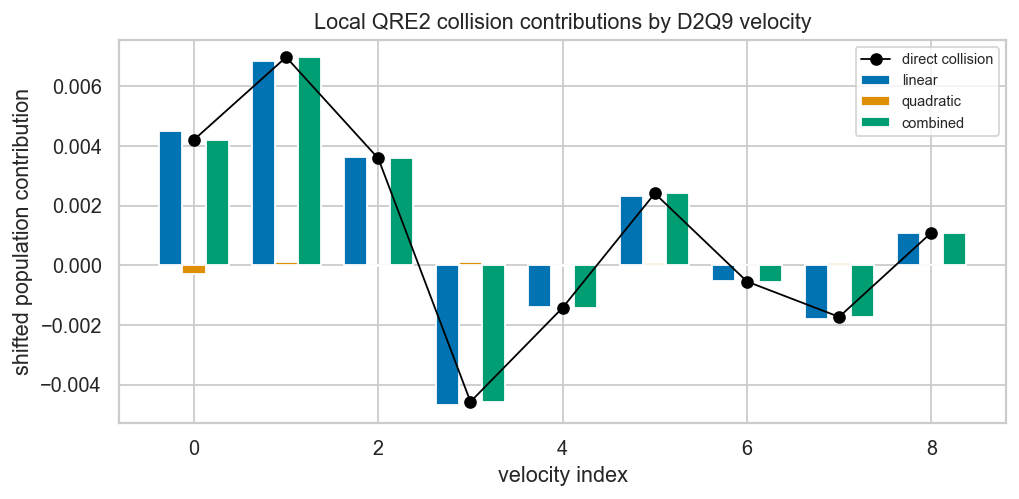

In [7]:
# Corpus anchor: QRE2 (`eq:F1`, `eq:F2`). Local shifted collision contribution storyboard.
site_state = tiny_g[:, 0, 0]
linear_contribution = (np.eye(9) + local_f1) @ site_state
quadratic_contribution = local_f2 @ np.kron(site_state, site_state)
combined_collision = linear_contribution + quadratic_contribution
direct_collision = site_state + (qre2.shifted_equilibrium(tiny_g)[:, 0, 0] - site_state) / tiny_tau
collision_residual = np.max(np.abs(combined_collision - direct_collision))
_fig, _ax = plt.subplots(figsize=(8, 4))
_ax.bar(velocity_indices - 0.25, linear_contribution, width=0.25, label='linear')
_ax.bar(velocity_indices, quadratic_contribution, width=0.25, label='quadratic')
_ax.bar(velocity_indices + 0.25, combined_collision, width=0.25, label='combined')
_ax.plot(velocity_indices, direct_collision, color='black', marker='o', linewidth=1, label='direct collision')
_ax.set_title('Local QRE2 collision contributions by D2Q9 velocity')
_ax.set_xlabel('velocity index')
_ax.set_ylabel('shifted population contribution')
_ax.legend(fontsize=8)
_fig.tight_layout()
print(f'local collision residual={collision_residual:.3e}')
print(f'linear contribution norm={np.linalg.norm(linear_contribution):.3e}')
print(f'quadratic contribution norm={np.linalg.norm(quadratic_contribution):.3e}')
print(f'combined collision norm={np.linalg.norm(combined_collision):.3e}')
assert collision_residual < 1e-12

## Taylor-Green Route Comparison

The algebra checks above prove the shifted operator on tiny states. This section puts the private `QRE2` shifted-D2Q9 route on the same periodic Taylor-Green benchmark surface as the standard BGK D2Q9 baseline.

This is a selected-observable behavior comparison, not an algebraic identity claim. The baseline evolves ordinary D2Q9 populations with density-scaled equilibrium; the `QRE2` route evolves shifted incompressible populations initialized from the same velocity and density-fluctuation moments.

Anchors: `QRE2` for the shifted operator; benchmark comparison surface from `QRE2`, `QRE4`, `LBM14`, and `CAR7`.

selected observable summaries
classical_bgk velocity_rel_l2=1.028e-02, vorticity_rel_l2=4.473e-03, kinetic_energy_rel=8.817e-03, divergence_rms=1.273e-03, max_mach=2.735e-02, mass_drift_rel=1.887e-15
qre2_shifted velocity_rel_l2=1.028e-02, vorticity_rel_l2=4.476e-03, kinetic_energy_rel=8.817e-03, divergence_rms=1.273e-03, max_mach=2.735e-02, mass_drift_rel=0.000e+00


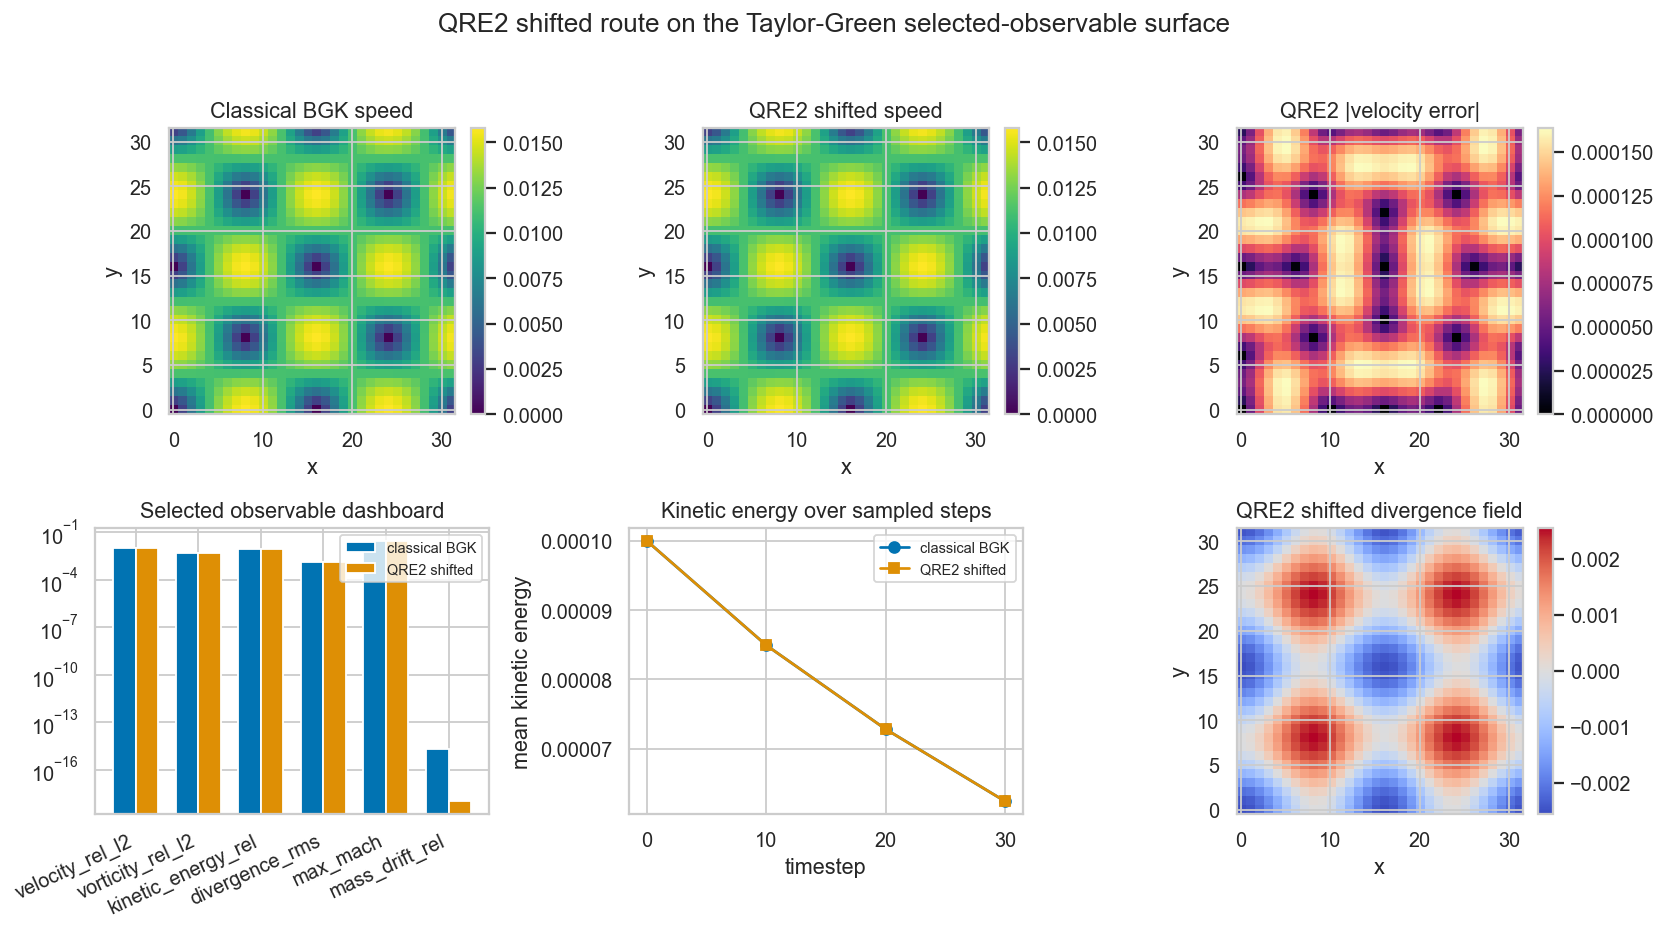

In [8]:
# Corpus anchors: QRE2, QRE4, LBM14, CAR7. Taylor-Green selected-observable route comparison.
def observable_summary(result):
    nx, ny = result.config.grid_shape
    spacing = grid_spacings((nx, ny))
    expected_velocity = analytic_taylor_green_velocity(result.config, nx, ny, result.config.steps)
    expected_vorticity = periodic_vorticity(expected_velocity, spacing=spacing)
    actual_vorticity = periodic_vorticity(result.velocity, spacing=spacing)
    divergence = periodic_divergence(result.velocity, spacing=spacing)
    expected_ke = mean_kinetic_energy(np.full((nx, ny), result.config.base_density), expected_velocity)
    actual_ke = mean_kinetic_energy(result.density, result.velocity)
    return {'velocity_rel_l2': relative_l2_error(result.velocity, expected_velocity), 'vorticity_rel_l2': relative_l2_error(actual_vorticity, expected_vorticity), 'kinetic_energy_rel': relative_scalar_error(actual_ke, expected_ke), 'divergence_rms': normalized_l2_norm(divergence), 'max_mach': max_mach_number(result.velocity), 'mass_drift_rel': float(result.metrics['mass_drift_relative'])}
tg_config = SimulationConfig(grid_shape=(32, 32), steps=30, tau=0.8, initial_condition='taylor_green', sample_interval=10, amplitude=0.02, base_density=1.0)
classical_bgk = run_d2q9(tg_config)
qre2_shifted = qre2.run_shifted_taylor_green(tg_config)
expected_velocity = analytic_taylor_green_velocity(tg_config, 32, 32, tg_config.steps)
qre2_velocity_error = speed(qre2_shifted.velocity - expected_velocity)
classical_summary = observable_summary(classical_bgk)
qre2_summary = observable_summary(qre2_shifted)
_fig, _axes = plt.subplots(2, 3, figsize=(13, 7))
plots = [(speed(classical_bgk.velocity), 'Classical BGK speed', 'viridis'), (speed(qre2_shifted.velocity), 'QRE2 shifted speed', 'viridis'), (qre2_velocity_error, 'QRE2 |velocity error|', 'magma')]
for _ax, (field, title, cmap) in zip(_axes[0], plots):
    image = _ax.imshow(field.T, origin='lower', cmap=cmap)
    _ax.set_title(title)
    _ax.set_xlabel('x')
    _ax.set_ylabel('y')
    _fig.colorbar(image, ax=_ax, fraction=0.046, pad=0.04)
observable_names = list(qre2_summary.keys())
xpos = np.arange(len(observable_names))
classical_values = np.array([max(classical_summary[name], 1e-18) for name in observable_names])
qre2_values = np.array([max(qre2_summary[name], 1e-18) for name in observable_names])
_axes[1, 0].bar(xpos - 0.18, classical_values, width=0.36, label='classical BGK')
_axes[1, 0].bar(xpos + 0.18, qre2_values, width=0.36, label='QRE2 shifted')
_axes[1, 0].set_yscale('log')
_axes[1, 0].set_xticks(xpos, observable_names, rotation=25, ha='right')
_axes[1, 0].set_title('Selected observable dashboard')
_axes[1, 0].legend(fontsize=8)
steps = np.array(qre2_shifted.history.steps)
qre2_ke = np.array([mean_kinetic_energy(rho, vel) for rho, vel in zip(qre2_shifted.history.density, qre2_shifted.history.velocity)])
classical_ke = np.array([mean_kinetic_energy(rho, vel) for rho, vel in zip(classical_bgk.history.density, classical_bgk.history.velocity)])
_axes[1, 1].plot(steps, classical_ke, marker='o', label='classical BGK')
_axes[1, 1].plot(steps, qre2_ke, marker='s', label='QRE2 shifted')
_axes[1, 1].set_title('Kinetic energy over sampled steps')
_axes[1, 1].set_xlabel('timestep')
_axes[1, 1].set_ylabel('mean kinetic energy')
_axes[1, 1].legend(fontsize=8)
qre2_div = periodic_divergence(qre2_shifted.velocity, spacing=grid_spacings(qre2_shifted.config.grid_shape))
image = _axes[1, 2].imshow(qre2_div.T, origin='lower', cmap='coolwarm', vmin=-np.max(np.abs(qre2_div)), vmax=np.max(np.abs(qre2_div)))
_axes[1, 2].set_title('QRE2 shifted divergence field')
_axes[1, 2].set_xlabel('x')
_axes[1, 2].set_ylabel('y')
_fig.colorbar(image, ax=_axes[1, 2], fraction=0.046, pad=0.04)
_fig.suptitle('QRE2 shifted route on the Taylor-Green selected-observable surface', y=1.02)
_fig.tight_layout()
print('selected observable summaries')
for _route, summary in (('classical_bgk', classical_summary), ('qre2_shifted', qre2_summary)):
    print(_route, ', '.join((f'{name}={value:.3e}' for name, value in summary.items())))
assert qre2_summary['max_mach'] < 0.1
assert np.isfinite(qre2_summary['velocity_rel_l2'])

grid=16x16, tau=0.7, vel_err=2.350e-02, mach=2.245e-02, mass=1.110e-16
grid=16x16, tau=0.8, vel_err=2.004e-02, mach=1.833e-02, mass=1.110e-16
grid=16x16, tau=0.9, vel_err=1.657e-02, mach=1.497e-02, mass=1.110e-16
grid=32x32, tau=0.7, vel_err=2.271e-02, mach=3.109e-02, mass=0.000e+00
grid=32x32, tau=0.8, vel_err=2.177e-02, mach=2.957e-02, mass=0.000e+00
grid=32x32, tau=0.9, vel_err=2.087e-02, mach=2.813e-02, mass=0.000e+00
grid=64x64, tau=0.7, vel_err=1.793e-02, mach=3.372e-02, mass=0.000e+00
grid=64x64, tau=0.8, vel_err=1.747e-02, mach=3.330e-02, mass=0.000e+00
grid=64x64, tau=0.9, vel_err=1.703e-02, mach=3.289e-02, mass=0.000e+00


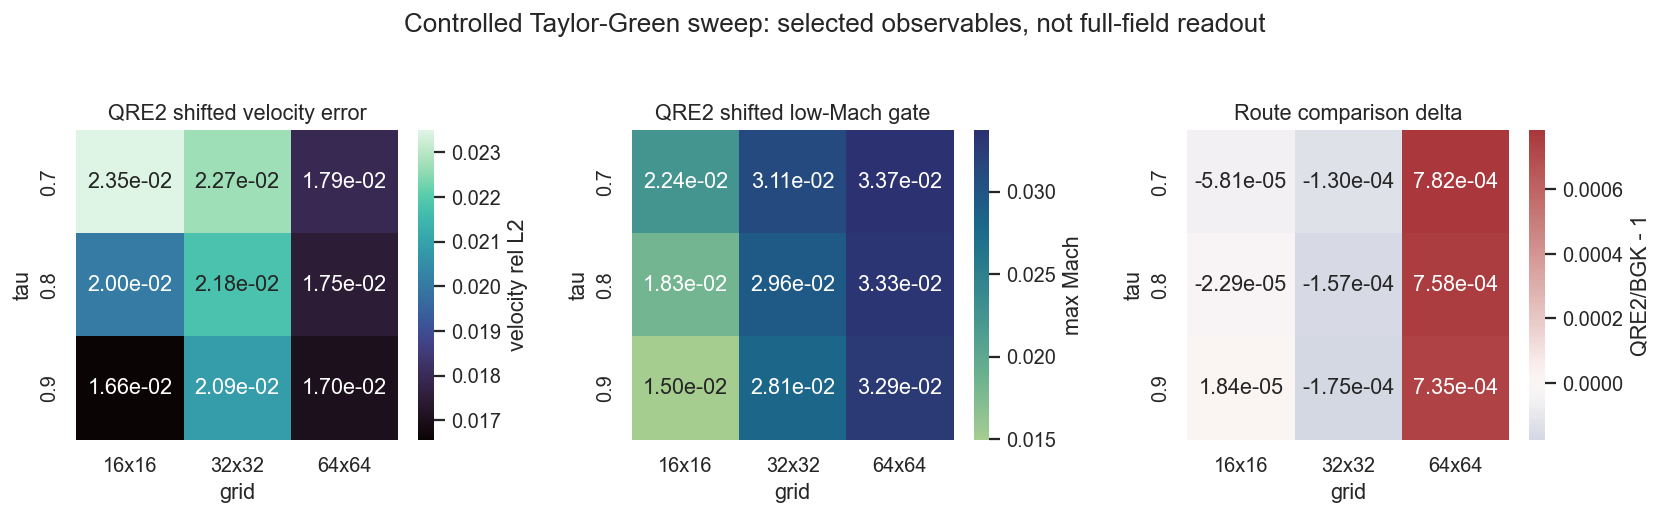

In [9]:
# Corpus anchors: QRE2, QRE4, LBM14, CAR7. Controlled route sweep with selected observables only.
sweep_rows = []
grids = ((16, 16), (32, 32), (64, 64))
taus = (0.7, 0.8, 0.9)
for grid_shape in grids:
    for tau in taus:
        config = SimulationConfig(grid_shape=grid_shape, steps=20, tau=tau, initial_condition='taylor_green', sample_interval=None, amplitude=0.02, base_density=1.0)
        for _route, result in (('classical_bgk', run_d2q9(config)), ('qre2_shifted', qre2.run_shifted_taylor_green(config))):
            row = {'grid': f'{grid_shape[0]}x{grid_shape[1]}', 'tau': tau, 'route': _route}
            row.update(observable_summary(result))
            sweep_rows.append(row)
qre2_velocity_grid = np.array([[next((row['velocity_rel_l2'] for row in sweep_rows if row['route'] == 'qre2_shifted' and row['grid'] == f'{grid[0]}x{grid[1]}' and (row['tau'] == tau))) for grid in grids] for tau in taus])
qre2_mach_grid = np.array([[next((row['max_mach'] for row in sweep_rows if row['route'] == 'qre2_shifted' and row['grid'] == f'{grid[0]}x{grid[1]}' and (row['tau'] == tau))) for grid in grids] for tau in taus])
ratio_grid = np.array([[next((row['velocity_rel_l2'] for row in sweep_rows if row['route'] == 'qre2_shifted' and row['grid'] == f'{grid[0]}x{grid[1]}' and (row['tau'] == tau))) / max(next((row['velocity_rel_l2'] for row in sweep_rows if row['route'] == 'classical_bgk' and row['grid'] == f'{grid[0]}x{grid[1]}' and (row['tau'] == tau))), 1e-18) for grid in grids] for tau in taus])
ratio_delta_grid = ratio_grid - 1.0
_fig, _axes = plt.subplots(1, 3, figsize=(13, 3.8))
labels = [f'{grid[0]}x{grid[1]}' for grid in grids]
sns.heatmap(qre2_velocity_grid, annot=True, fmt='.2e', cmap='mako', ax=_axes[0], xticklabels=labels, yticklabels=taus, cbar_kws={'label': 'velocity rel L2'})
_axes[0].set_title('QRE2 shifted velocity error')
_axes[0].set_xlabel('grid')
_axes[0].set_ylabel('tau')
sns.heatmap(qre2_mach_grid, annot=True, fmt='.2e', cmap='crest', ax=_axes[1], xticklabels=labels, yticklabels=taus, cbar_kws={'label': 'max Mach'})
_axes[1].set_title('QRE2 shifted low-Mach gate')
_axes[1].set_xlabel('grid')
_axes[1].set_ylabel('tau')
sns.heatmap(ratio_delta_grid, annot=True, fmt='.2e', cmap='vlag', center=0, ax=_axes[2], xticklabels=labels, yticklabels=taus, cbar_kws={'label': 'QRE2/BGK - 1'})
_axes[2].set_title('Route comparison delta')
_axes[2].set_xlabel('grid')
_axes[2].set_ylabel('tau')
_fig.suptitle('Controlled Taylor-Green sweep: selected observables, not full-field readout', y=1.04)
_fig.tight_layout()
for row in sweep_rows:
    if row['route'] == 'qre2_shifted':
        print(f"grid={row['grid']}, tau={row['tau']}, vel_err={row['velocity_rel_l2']:.3e}, mach={row['max_mach']:.3e}, mass={row['mass_drift_rel']:.3e}")
assert np.all(np.isfinite(qre2_velocity_grid))
assert np.max(qre2_mach_grid) < 0.1

## Dependency And Public API Guard

The migration deliberately avoids public API expansion and avoids quantum/resource packages. The private module can be imported for this handoff, but `pq_cfd.__all__` stays focused on baseline and diagnostic APIs.

`seaborn` is allowed only as a notebook visualization extra. It is not a runtime dependency and not quantum tooling.

In [ ]:
# Corpus anchor: QRE2. Guard against public API expansion and blocked quantum/resource package drift.
import tomllib

pyproject = tomllib.loads((project_root / "pyproject.toml").read_text(encoding="utf-8"))
runtime_deps = pyproject["project"]["dependencies"]
notebook_deps = pyproject["project"]["optional-dependencies"]["notebook"]
dev_deps = pyproject["dependency-groups"]["dev"]
blocked_names = ("qiskit", "qualtran", "azure", "qlbm")
all_declared = runtime_deps + notebook_deps + dev_deps

assert not any("qre2" in name.lower() for name in pq_cfd.__all__)
assert not any(any(blocked in dep.lower() for blocked in blocked_names) for dep in all_declared)
assert any("seaborn" in dep.lower() for dep in notebook_deps)
print(f"runtime dependencies: {runtime_deps}")
print(f"notebook dependencies: {notebook_deps}")
print(f"dev dependencies: {dev_deps}")
print("private QRE2 module remains outside pq_cfd.__all__")

runtime dependencies: ['bartiq==0.17.0', 'numpy>=2.0', 'qref==0.11.0', 'scipy>=1.17']
notebook dependencies: ['ipykernel>=6.29', 'jupyterlab>=4.3', 'matplotlib>=3.9', 'nbconvert>=7.16', 'nbformat>=5.10', 'seaborn>=0.13']
dev dependencies: ['pytest>=8.3']
private QRE2 module remains outside pq_cfd.__all__


: 

## Verification Commands

Run these from the repository root after editing this notebook or the shifted operator:

```powershell
uv run pytest tests/test_qre2_shifted.py -q
uv run pytest
uv run --extra notebook jupyter nbconvert --to notebook --execute --output-dir .cache/notebooks notebooks/qre2_shifted_operator_handoff.ipynb
uv run --extra notebook jupyter lab notebooks/qre2_shifted_operator_handoff.ipynb
```

This notebook is the official pre-Carleman operator gate for `QRE2`. If it executes and the tests pass, the next route discussion can focus on the smallest dense Carleman lift validation, still without quantum packages or circuit code.